In [1]:
import sqlite3
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

sns.set_style("whitegrid")

In [2]:
conn = sqlite3.connect("bluestock_mf.db")

# Check Tables

In [3]:
pd.read_sql("""
SELECT name
FROM sqlite_master
WHERE type='table'
""", conn)

,name
0,dim_fund
1,fact_nav
2,fact_transactions
3,fact_performance
4,fact_aum


# Load NAV Data

In [4]:
query = """
SELECT
amfi_code,
date,
nav
FROM fact_nav
"""

nav_df = pd.read_sql(query, conn)

nav_df['date'] = pd.to_datetime(nav_df['date'])

nav_df.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


# Compute Daily Returns

In [5]:
nav_df = nav_df.sort_values(
    ['amfi_code','date']
)

nav_df['daily_return'] = (
    nav_df.groupby('amfi_code')['nav']
    .pct_change()
)

nav_df.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


# Daily Return Distribution Chart

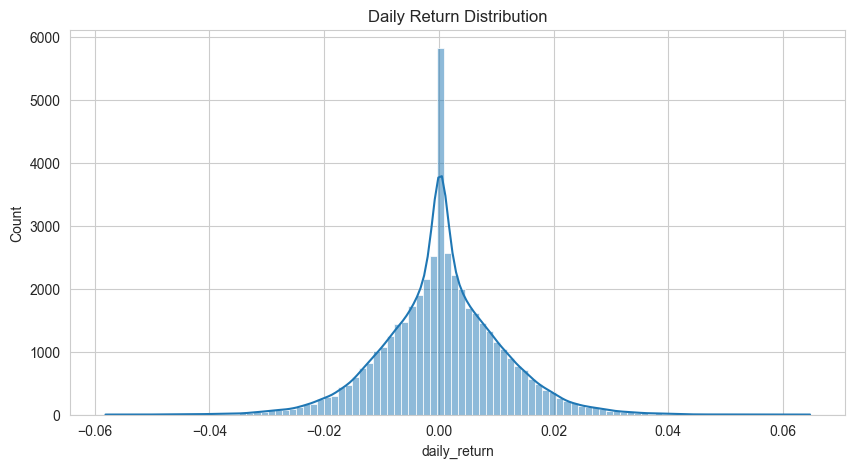

In [7]:
plt.figure(figsize=(10,5))

sns.histplot(
    nav_df['daily_return'].dropna(),
    bins=100,
    kde=True
)

plt.title("Daily Return Distribution")

plt.savefig(
    "daily_return_distribution.png"
)

plt.show()

# CAGR Calculation

In [8]:
cagr_results = []

for fund in nav_df['amfi_code'].unique():

    temp = nav_df[
        nav_df['amfi_code']==fund
    ]

    start_nav = temp.iloc[0]['nav']

    end_nav = temp.iloc[-1]['nav']

    years = (
        temp['date'].max()
        -
        temp['date'].min()
    ).days/365

    cagr = (
        (end_nav/start_nav)
        **
        (1/years)
        -1
    )

    cagr_results.append(
        [fund,cagr]
    )

cagr_df = pd.DataFrame(
    cagr_results,
    columns=[
        'amfi_code',
        'cagr'
    ]
)

cagr_df.head()

,amfi_code,cagr
0,100016,0.026352
1,100025,0.044551
2,100033,0.300997
3,101206,0.235205
4,101207,0.079331


# Save CAGR Table

In [9]:
cagr_df.to_csv(
    "cagr_table.csv",
    index=False
)

# Sharpe Ratio

In [10]:
rf = 0.065

sharpe_list = []

for fund in nav_df['amfi_code'].unique():

    temp = nav_df[
        nav_df['amfi_code']==fund
    ]

    annual_return = (
        temp['daily_return'].mean()
        *252
    )

    volatility = (
        temp['daily_return'].std()
        *np.sqrt(252)
    )

    sharpe = (
        annual_return-rf
    ) / volatility

    sharpe_list.append(
        [fund,sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_list,
    columns=[
        'amfi_code',
        'sharpe_ratio'
    ]
)

sharpe_df.sort_values(
    'sharpe_ratio',
    ascending=False
).head()

,amfi_code,sharpe_ratio
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101


# Export Sharpe Rankings

In [11]:
sharpe_df.to_csv(
    "sharpe_ratio_rankings.csv",
    index=False
)

# Sortino Ratio

In [12]:
sortino_list = []

for fund in nav_df['amfi_code'].unique():

    temp = nav_df[
        nav_df['amfi_code']==fund
    ]

    downside = temp[
        temp['daily_return'] < 0
    ]['daily_return']

    downside_std = (
        downside.std()
        *np.sqrt(252)
    )

    annual_return = (
        temp['daily_return'].mean()
        *252
    )

    sortino = (
        annual_return-rf
    ) / downside_std

    sortino_list.append(
        [fund,sortino]
    )

sortino_df = pd.DataFrame(
    sortino_list,
    columns=[
        'amfi_code',
        'sortino_ratio'
    ]
)

sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


# Export Sortino

In [13]:
sortino_df.to_csv(
    "sortino_ratio_rankings.csv",
    index=False
)

# Maximum Drawdown

In [14]:
dd_results = []

for fund in nav_df['amfi_code'].unique():

    temp = nav_df[
        nav_df['amfi_code']==fund
    ].copy()

    temp['running_max'] = (
        temp['nav'].cummax()
    )

    temp['drawdown'] = (
        temp['nav']
        /
        temp['running_max']
        -1
    )

    max_dd = (
        temp['drawdown'].min()
    )

    dd_results.append(
        [fund,max_dd]
    )

dd_df = pd.DataFrame(
    dd_results,
    columns=[
        'amfi_code',
        'max_drawdown'
    ]
)

dd_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


# Check Performance Table Structure

In [15]:
pd.read_sql("""
PRAGMA table_info(fact_performance)
""", conn)

,cid,name,type,notnull,dflt_value,pk
0,0,amfi_code,BIGINT,0,None,0
1,1,scheme_name,TEXT,0,None,0
2,2,fund_house,TEXT,0,None,0
3,3,category,TEXT,0,None,0
4,4,plan,TEXT,0,None,0
5,5,return_1yr_pct,FLOAT,0,None,0
6,6,return_3yr_pct,FLOAT,0,None,0
7,7,return_5yr_pct,FLOAT,0,None,0
8,8,benchmark_3yr_pct,FLOAT,0,None,0
9,9,alpha,FLOAT,0,None,0


# Load Performance Data

In [16]:
performance = pd.read_sql("""
SELECT *
FROM fact_performance
""", conn)

performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


# Alpha-Beta Table

In [17]:
alpha_beta = performance[
    [
        'amfi_code',
        'scheme_name',
        'alpha',
        'beta'
    ]
]

alpha_beta.head()

,amfi_code,scheme_name,alpha,beta
0,119551,SBI Bluechip Fund - Regular Plan - Growth,0.87,0.89
1,119552,SBI Bluechip Fund - Direct Plan - Growth,1.78,0.87
2,119598,SBI Small Cap Fund - Regular Plan - Growth,1.23,0.89
3,119599,SBI Small Cap Fund - Direct Plan - Growth,1.13,1.04
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,1.60,0.22


# Export alpha_beta.csv

In [18]:
alpha_beta.to_csv(
    "alpha_beta.csv",
    index=False
)

# Fund Scorecard

30% × 3yr return rank
25% × Sharpe rank
20% × Alpha rank
15% × Expense Ratio rank (inverse)
10% × Max Drawdown rank (inverse)

In [22]:
scorecard = performance.copy()

# Rank 3-Year Returns

In [23]:
scorecard['return_rank'] = (
    scorecard['return_3yr_pct']
    .rank(pct=True)
)

# Rank Sharpe

In [24]:
scorecard['sharpe_rank'] = (
    scorecard['sharpe_ratio']
    .rank(pct=True)
)

# Rank Alpha

In [25]:
scorecard['alpha_rank'] = (
    scorecard['alpha']
    .rank(pct=True)
)

# Expense Ratio (Lower Better)

In [26]:
scorecard['expense_rank'] = (
    scorecard['expense_ratio_pct']
    .rank(
        pct=True,
        ascending=False
    )
)

# Drawdown (Lower Better)

In [27]:
scorecard['dd_rank'] = (
    scorecard['max_drawdown_pct']
    .rank(
        pct=True,
        ascending=False
    )
)

# Composite Score

In [28]:
scorecard['fund_score'] = (

    scorecard['return_rank']*30 +

    scorecard['sharpe_rank']*25 +

    scorecard['alpha_rank']*20 +

    scorecard['expense_rank']*15 +

    scorecard['dd_rank']*10

)

# Top Funds

In [29]:
scorecard[
    [
        'scheme_name',
        'fund_score'
    ]
].sort_values(
    'fund_score',
    ascending=False
).head(10)

,scheme_name,fund_score
3,SBI Small Cap Fund - Direct Plan - Growth,72.7500
22,Kotak Flexicap Fund - Regular - Growth,71.5000
21,Kotak Emerging Equity Fund - Regular - Growth,70.5000
29,ABSL Small Cap Fund - Regular - Growth,68.2500
2,SBI Small Cap Fund - Regular Plan - Growth,64.3750
34,Mirae Asset Large Cap Fund - Regular - Growth,63.9375
9,HDFC Short Term Debt Fund - Regular - Growth,63.0000
14,ICICI Pru Liquid Fund - Regular - Growth,61.7500
12,ICICI Pru Midcap Fund - Regular - Growth,61.0000
11,ICICI Pru Bluechip Fund - Direct - Growth,59.6250


# Export Fund Scorecard

In [30]:
scorecard.to_csv(
    "fund_scorecard.csv",
    index=False
)

# Top 10 Fund Score Chart

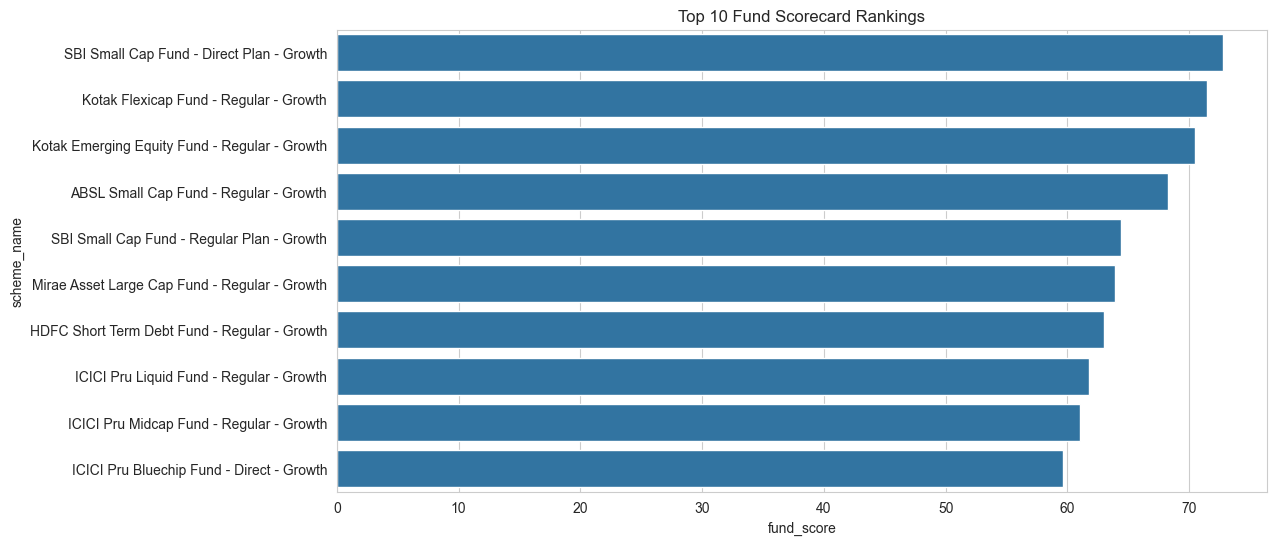

In [31]:
top10 = scorecard.sort_values(
    'fund_score',
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x='fund_score',
    y='scheme_name'
)

plt.title(
    "Top 10 Fund Scorecard Rankings"
)

plt.savefig(
    "fund_scorecard.png"
)

plt.show()

# Benchmark Comparison Chart

In [32]:
top5 = scorecard.sort_values(
    'fund_score',
    ascending=False
).head(5)

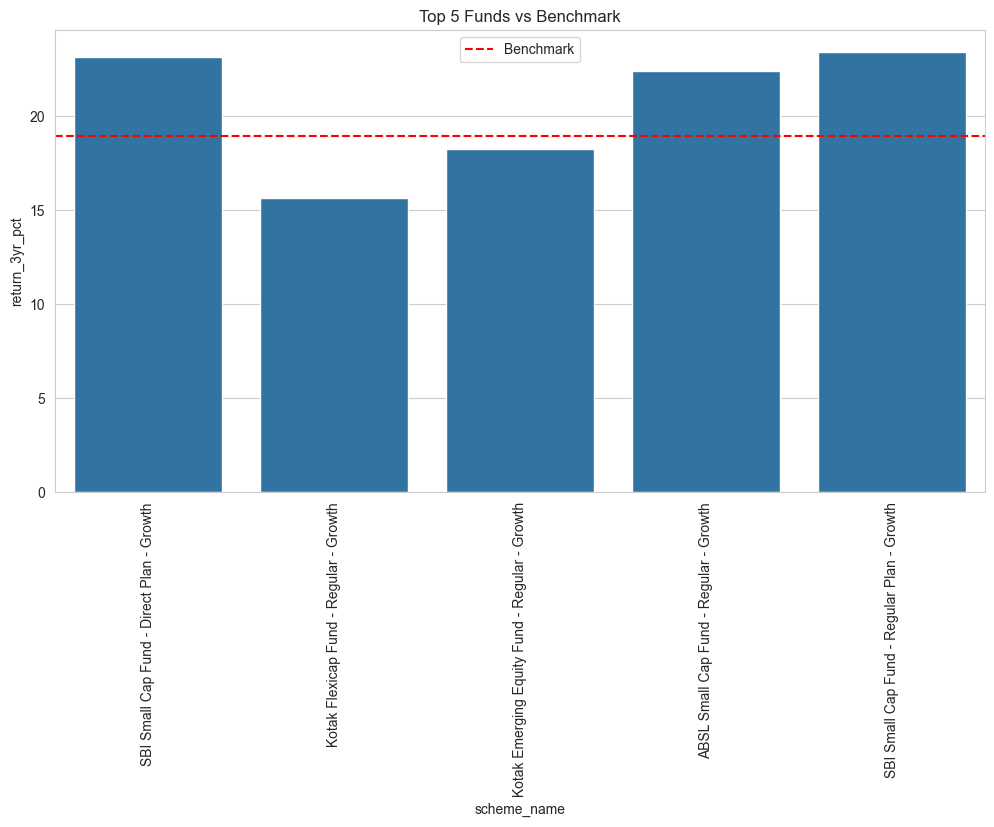

In [33]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top5,
    x='scheme_name',
    y='return_3yr_pct'
)

plt.xticks(rotation=90)

plt.axhline(
    y=top5['benchmark_3yr_pct'].mean(),
    color='red',
    linestyle='--',
    label='Benchmark'
)

plt.legend()

plt.title(
    "Top 5 Funds vs Benchmark"
)

plt.savefig(
    "benchmark_comparison.png"
)

plt.show()

# Markdown Insights

1. Small-cap funds dominate top performance rankings.

2. Top-ranked funds consistently outperform benchmark returns.

3. Higher Sharpe ratios indicate superior risk-adjusted performance.

4. Lower expense ratio funds generally receive better composite scores.

5. Maximum drawdown significantly impacts fund rankings.

6. Alpha values show several funds generated excess returns.

7. Beta values indicate varying sensitivity to market movements.

8. Top funds achieved strong 3-year CAGR performance.

9. Risk-adjusted metrics provide better evaluation than raw returns.

10. Composite scorecard effectively identifies well-balanced funds.

In [34]:
import os
os.listdir()

['.git',
 '.ipynb_checkpoints',
 'alpha_beta.csv',
 'amfi_validation.py',
 'benchmark_comparison.png',
 'bluestock_mf.db',
 'cagr_table.csv',
 'daily_return_distribution.png',
 'dashboard',
 'data',
 'data_cleaning.py',
 'data_ingestion.py',
 'EDA_Analysis.ipynb',
 'FULL_PATH_TO_DATABASE',
 'fund_scorecard.csv',
 'fund_scorecard.png',
 'live_nav_fetch.py',
 'load_to_sqlite.py',
 'mf-analytics',
 'mutual_funds.db',
 'notebooks',
 'Performance_Analytics.ipynb',
 'reports',
 'requirements.txt',
 'sharpe_ratio_rankings.csv',
 'sortino_ratio_rankings.csv',
 'sql',
 'Untitled.ipynb']